In [1]:
# If the Python version is > 3.12, please comment out the following line, otherwise matplotlib will not display the images
# %matplotlib inline
%time from hikyuu.interactive import *
iodog.open()

Initialize hikyuu_2.8.2_202609250345_RELEASE_macosx_arm64 ...
2026-09-25 13:44:23.184 [HKU-I] - current python version: 3.13.12 (main.cpp:77)


2026-09-25 13:44:24,591 [INFO] runing in interactive session [<module>] (/Users/fasiondog/workspace/hikyuu/hikyuu/__init__.py:149) [hikyuu::hku_info]
2026-09-25 13:44:24,591 [INFO] running in jupyter [<module>] (/Users/fasiondog/workspace/hikyuu/hikyuu/__init__.py:156) [hikyuu::hku_info]


2026-09-25 13:44:24.595 [HKU-I] - 插件路径: /Users/fasiondog/workspace/hku_plugin/hikyuu_plugin (StockManager.cpp:124)
2026-09-25 13:44:24.629 [HKU-I] - Using CLICKHOUSE BaseInfoDriver (BaseInfoDriver.cpp:56)
2026-09-25 13:44:24.640 [HKU-I] - Mapped hikyuu kdata shm cache: hikyuu_ks_000001a0d717ce65 (epoch: 1790315056741, covered stock entries: 8968) (IpcConnector.cpp:174)
2026-09-25 13:44:24.640 [HKU-I] - Mapped hikyuu base info shm cache: hikyuu_bi_000001a0d717adb9 (epoch: 1790315048377, covered stock entries: 6512, finance fields: 0) (IpcConnector.cpp:191)
2026-09-25 13:44:24.641 [HKU-I] - Connected to hikyuu shm server: ipc:///var/folders/5m/v_9j2xl169l9_sqhbbwsxkx40000gn/T//hikyuu_shm_server_3445e4360a34698b.ipc, running in client mode. (StockManager.cpp:288)
2026-09-25 13:44:24.652 [HKU-I] - 加载市场信息…… (StockManager.cpp:1050)
2026-09-25 13:44:24.652 [HKU-I] - 加载证券类型信息…… (StockManager.cpp:1067)
2026-09-25 13:44:24.652 [HKU-I] - 加载证券信息…… (StockManager.cpp:948)
2026-09-25 13:44:24.755 [HK

# 一、策略分析

## 原始描述

买入条件：周线MACD零轴下方底部金叉买入30%

卖出条件：日线级别 跌破 20日线 卖出50%持仓


## 策略分析

市场环境：无

系统有效性：无

信号指示器：
- 买入信号：周线MACD零轴下方底部金叉，即周线的DIF>DEA金叉时买入（快线：DIF，慢线DEA）
- 卖出信号：日线级别 跌破 20日均线

止损/止盈：无

资金管理：
- 买入：30% （不明确，暂且当做当前现金的30%）
- 卖出：已持仓股票数的50%

盈利目标：

移滑价差：


# 二、实现系统部件

## 定义信号指示器

In [2]:
def getNextWeekDate(week):
    """Get the date of the next Monday after the given date"""
    from datetime import timedelta
    py_week = week.datetime()
    next_week_start = py_week + timedelta(days = 7 - py_week.weekday())
    return Datetime(next_week_start)

In [3]:
def DEMO_SG(self, k):
    """
    Buy signal: the weekly MACD golden cross below the zero axis, i.e. buy when the weekly DIF crosses above DEA
    Sell signal: the daily level falls below the 20-day moving average
    
    Parameters:
    week_macd_n1: the weekly DIF window
    week_macd_n2: the weekly DEA window
    week_macd_n3: the weekly MACD smoothing window
    day_n: the daily moving-average window
    """
    if (len(k) == 0):
        return
    
    stk = k.get_stock()
    
    #-----------------------------
    # Calculate the daily sell signal        
    #-----------------------------
    day_c = CLOSE(k)
    day_ma = MA(day_c, self.get_param("day_n"))
    day_x = day_c < day_ma  # The close price is below the moving average
    for i in range(day_x.discard, len(day_x)):
        if day_x[i] >= 1.0:
            self._add_sell_signal(k[i].datetime)

    #-----------------------------
    # Calculate the weekly buy signal        
    #-----------------------------
    week_q = Query(k[0].datetime, k[-1].datetime.next_day(), ktype=Query.WEEK)
    week_k = k.get_stock().get_kdata(week_q)
    
    n1 = self.get_param("week_macd_n1")
    n2 = self.get_param("week_macd_n2")
    n3 = self.get_param("week_macd_n3")
    m = MACD(CLOSE(week_k), n1, n2, n3)
    fast = m.get_result(1)
    slow = m.get_result(2)
    
    discard = m.discard if m.discard > 1 else 1
    for i in range(discard, len(m)):
        if (fast[i-1] < slow[i-1] and fast[i] > slow[i]):
            # The result calculated in the current week can only be used as the signal for the next Monday
            self._add_buy_signal(week_k[i].datetime.next_week())
         

## 定义资金管理策略

In [4]:
class DEMO_MM(MoneyManagerBase):
    """
    Buy: 30% (ambiguous, treat it as 30% of the current cash for now)
    Sell: 50% of the held shares
    """
    def __init__(self):
        super(DEMO_MM, self).__init__("MACD_MM")
        
    def _reset(self):
        pass
    
    def _clone(self):
        return DEMO_MM()
        
    def _get_buy_num(self, datetime, stk, price, risk, part_from):
        tm = self.tm
        cash = tm.current_cash
        
        # No need to consider the minimum trading unit, it is handled automatically
        # return int(cash*0.3/price) # The return type must be int
        return cash / price
    
    def _get_sell_num(self, datetime, stk, price, risk, part_from):
        tm = self.tm
        position = tm.get_position(datetime, stk)
        total_num = position.number
        num = int(total_num * 0.5)
        return num if num >= 100 else 0

# 三、构建并运行系统

## 设定系统参数


In [5]:
# Account parameters
init_cash = 100000 # Account initial capital
init_date = Datetime('1990-1-1') # Account creation date

# Signal generator parameters
week_n1 = 12
week_n2 = 26
week_n3 = 9
day_n = 20

# Select the target and the test range
stk = sm['sz000001']
start_date = Datetime('2017-01-01')  # If it is the same K-line level, the index number can be used; if different K-line levels are used, it is recommended to use the date as the parameter
end_date = Datetime()

## 构建系统实例

In [6]:
# Create the account
my_tm = crtTM(date=init_date, init_cash = init_cash, cost_func=TC_FixedA())

# Create the system instance
my_sys = SYS_Simple()

# Bind the account
my_sys.tm = my_tm

# Bind the signal generator
# !Note
# Restricted by the pybind11 limitation, you cannot directly use my_sys.sg = crtSG( or my_sys.mm = DEMO_MM(); you must create the Python object instance first and then assign it
my_sg = crtSG(DEMO_SG, 
              {'week_macd_n1': week_n1, 'week_macd_n2': week_n2, 'week_macd_n3': week_n3, 'day_n': day_n}, 
                'DEMO_SG') 
my_sys.sg = my_sg
my_sys.sg.set_param('alternate', False)

# Bind the money management strategy
my_mm = DEMO_MM()
my_sys.mm = my_mm

## 运行系统

In [7]:
iodog.close()
q = Query(start_date, end_date, ktype=Query.DAY)
my_sys.run(stk, q)

# Save the trade records and positions to a temporary directory, which can be viewed with Excel
# The temporary directory is usually set to the tmp subdirectory under the data directory
# If the excel records are open, remember to close the excel file before running the system again; otherwise the new results cannot be saved
my_tm.tocsv(sm.tmpdir())

# 四、查看资金曲线及绩效统计

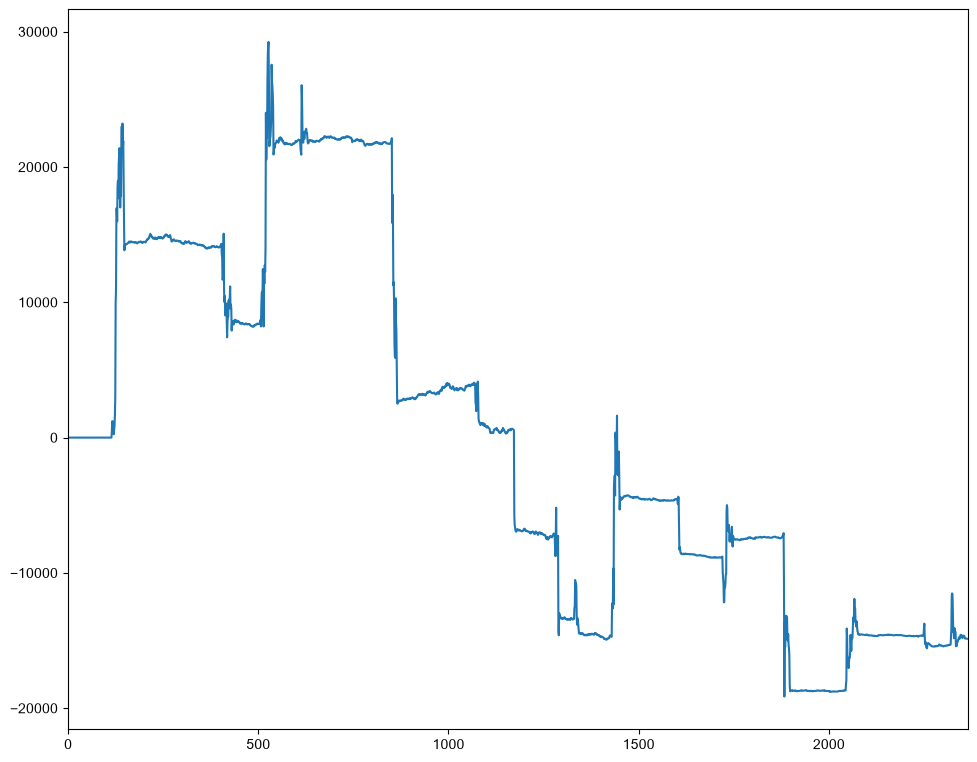

In [8]:
# Draw the equity return curve (net income)
x = my_tm.get_profit_curve(stk.get_datetime_list(q), Query.DAY)
#x = my_tm.getFundsCurve(stk.getDatetimeList(q), KQuery.DAY) # Total assets curve
x = PRICELIST(x)
x.plot()

In [9]:
# Backtest statistics
per = my_tm.get_performance()
per.statistics(my_tm, Datetime.now())
print(per.report())

帐户初始金额: 100000.00
累计投入本金: 100000.00
累计投入资产: 0.00
累计借入现金: 0.00
累计借入资产: 0.00
累计红利: 6251.36
现金余额: 83799.69
未平仓头寸净值: 1333.40
当前总资产: 85133.09
已平仓交易总成本: 0.00
已平仓净利润总额: 0.00
单笔交易最大占用现金比例%: 99.89
交易平均占用现金比例%: 99.23
未平仓帐户收益率%: -14.87
已平仓帐户收益率%: 0.00
帐户年复合收益率%: -1.72
帐户平均年收益率%: -1.61
赢利交易赢利总额: 0.00
亏损交易亏损总额: 0.00
已平仓交易总数: 0.00
赢利交易数: 0.00
亏损交易数: 0.00
赢利交易比例%: 0.00
赢利期望值: 0.00
赢利交易平均赢利: 0.00
亏损交易平均亏损: 0.00
平均赢利/平均亏损比例: 0.00
净赢利/亏损比例: 0.00
最大单笔赢利: 0.00
最大单笔盈利百分比%: 0.00
最大单笔亏损: 0.00
最大单笔亏损百分比%: 0.00
赢利交易平均持仓时间: 0.00
赢利交易最大持仓时间: 0.00
亏损交易平均持仓时间: 0.00
亏损交易最大持仓时间: 0.00
空仓总时间: 3378.00
空仓时间/总时间%: 100.00
平均空仓时间: 3378.00
最长空仓时间: 3377.00
最大连续赢利笔数: 0.00
最大连续亏损笔数: 0.00
最大连续赢利金额: 0.00
最大连续亏损金额: 0.00
R乘数期望值: 0.00
交易机会频率/年: 0.00
年度期望R乘数: 0.00
赢利交易平均R乘数: 0.00
亏损交易平均R乘数: 0.00
最大单笔赢利R乘数: 0.00
最大单笔亏损R乘数: 0.00
最大连续赢利R乘数: 0.00
最大连续亏损R乘数: 0.00
最大回撤百分比: 0.00
夏普比率: 0.00
单笔交易盈亏百分比均值: 0.00
单笔交易盈亏百分比标准差: nan



<Axes: title={'center': '账户(SYS) 累积收益率'}>

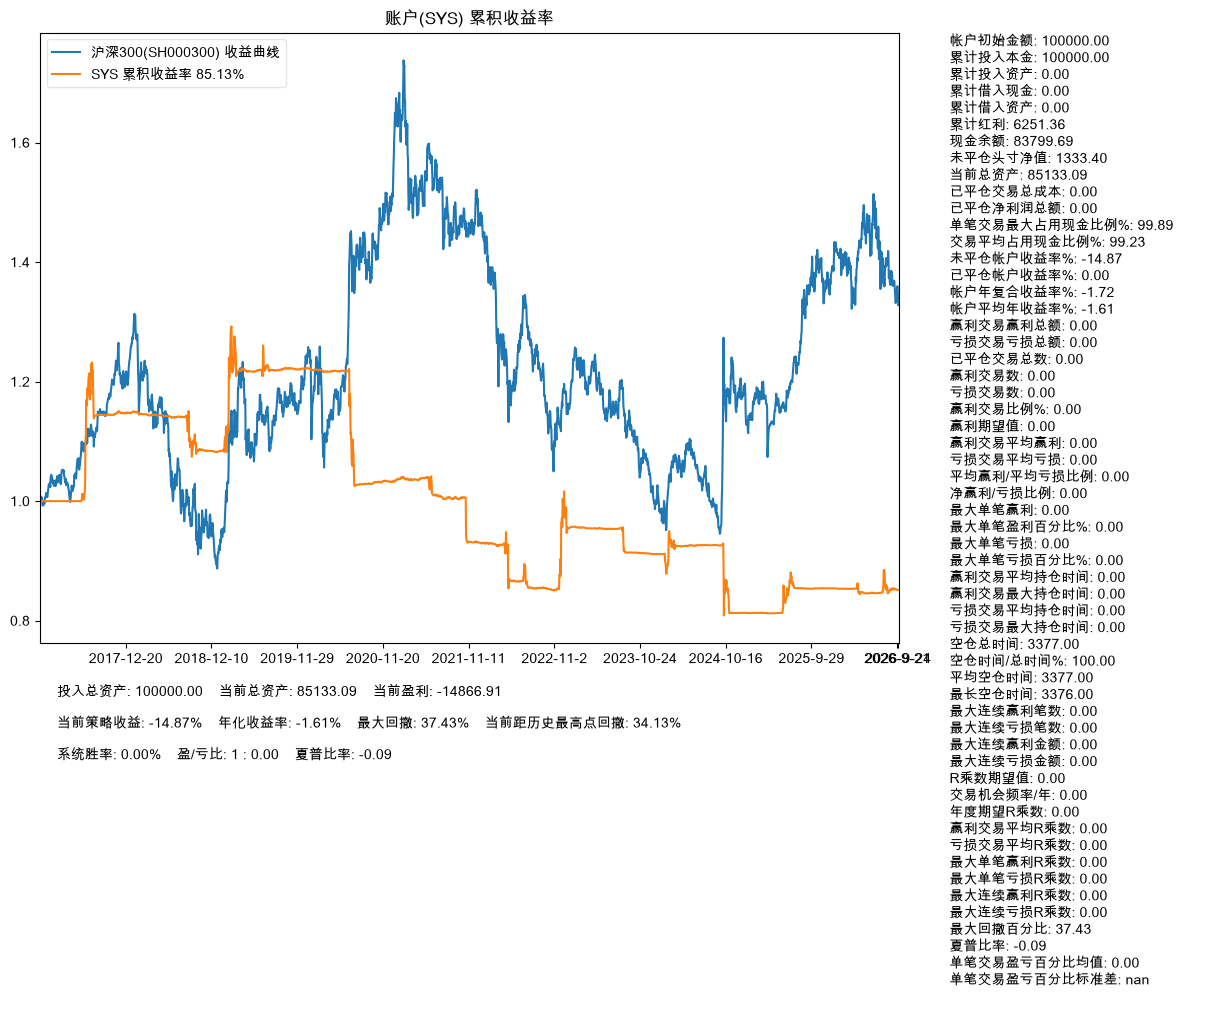

In [10]:
my_sys.performance()

# 五、或许想看下图形

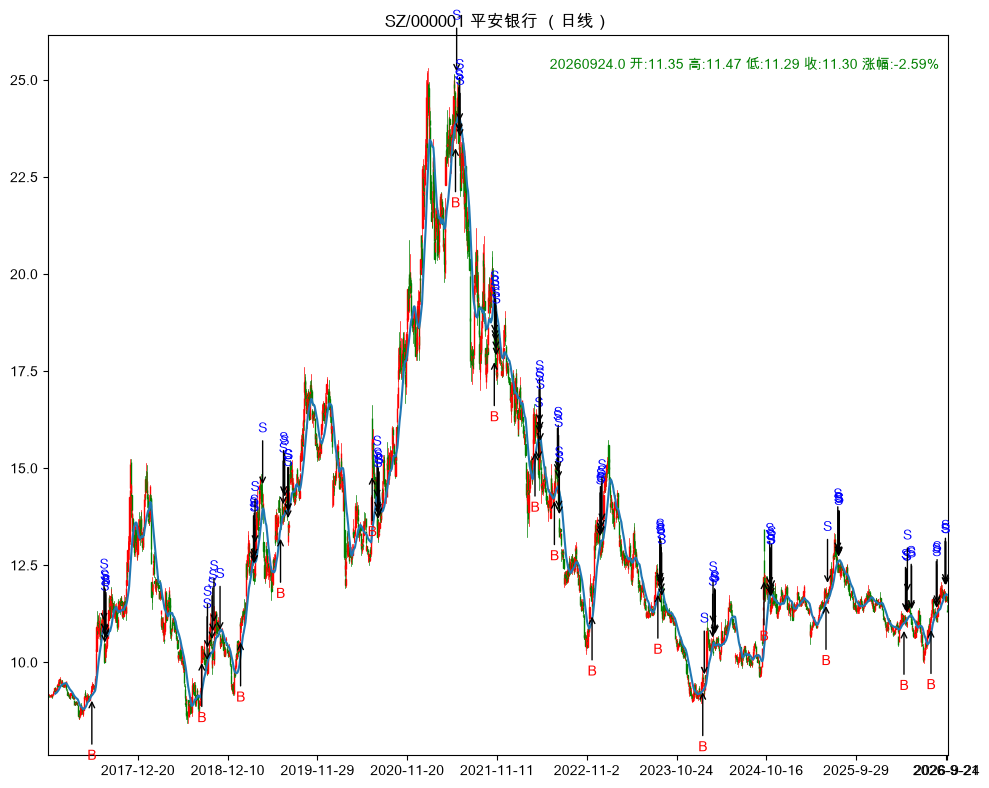

In [11]:
my_sys.plot()
MA(CLOSE(my_sys.to), 20).plot(new=False)

# 六、或许想看看所有股票的情况

In [12]:
import pandas as pd
def calTotal(blk, q):
    per = Performance()
    s_name = []
    s_code = []
    x = []
    for stk in blk:
        my_sys.run(stk, q)
        per.statistics(my_tm, Datetime.now())
        s_name.append(stk.name)
        s_code.append(stk.market_code)
        x.append(per["Current Total Assets"])
    return pd.DataFrame({'code': s_code, 'name': s_name, 'total_assets': x})

%time data = calTotal(blocka, q)

CPU times: user 42.8 s, sys: 1.79 s, total: 44.6 s
Wall time: 3min 12s


In [13]:
# Save to a CSV file
# data.to_csv(sm.tmpdir() + '/statistics.csv')
data[:10]

,code,name,total_assets
0,SZ002465,海格通信,64494.74
1,SZ002380,科远智慧,49141.26
2,SH600208,衢州发展,157813.50
3,SZ000509,华塑控股,42865.33
4,SZ000513,丽珠集团,116469.52
5,SH603683,晶华新材,56571.49
6,SZ002509,天茂退,100000.00
7,SZ002657,中科金财,54595.76
8,SH600237,铜峰电子,44111.69
9,SZ002532,天山铝业,68478.44
